# 🔍 23 - Inset Plots & Zoomed Views

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset, zoomed_inset_axes

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Libraries imported")

✅ Libraries imported


## 🎯 Learning Objectives

- Creating inset axes within a plot
- Zooming into specific regions
- Adding magnified views
- Picture-in-picture plots
- Connecting insets to main plot
- Custom inset positioning

## 📍 1. Basic Inset Plot

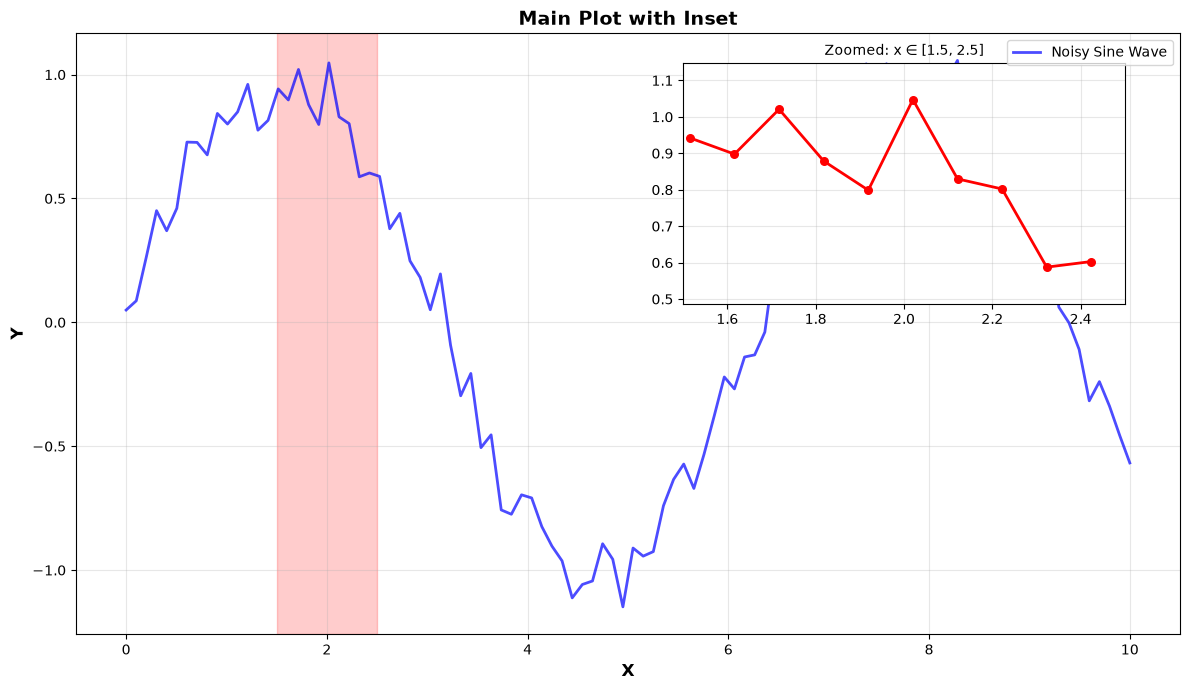

In [2]:
# Generate data
np.random.seed(42)
x = np.linspace(0, 10, 100)
y = np.sin(x) + 0.1 * np.random.randn(100)

fig, ax = plt.subplots(figsize=(12, 7))

# Main plot
ax.plot(x, y, 'b-', linewidth=2, alpha=0.7, label='Noisy Sine Wave')
ax.set_xlabel('X', fontsize=12, fontweight='bold')
ax.set_ylabel('Y', fontsize=12, fontweight='bold')
ax.set_title('Main Plot with Inset', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Create inset axes
ax_inset = ax.inset_axes([0.55, 0.55, 0.4, 0.4])  # [x, y, width, height] in axes coordinates

# Plot zoomed region in inset
x_zoom = np.linspace(1.5, 2.5, 20)
y_zoom_idx = np.where((x >= 1.5) & (x <= 2.5))[0]
ax_inset.plot(x[y_zoom_idx], y[y_zoom_idx], 'r-', linewidth=2)
ax_inset.scatter(x[y_zoom_idx], y[y_zoom_idx], c='red', s=30, zorder=5)
ax_inset.set_xlim(1.5, 2.5)
ax_inset.set_ylim(y[y_zoom_idx].min() - 0.1, y[y_zoom_idx].max() + 0.1)
ax_inset.grid(True, alpha=0.3)
ax_inset.set_title('Zoomed: x ∈ [1.5, 2.5]', fontsize=10)

# Highlight the zoomed region on main plot
ax.axvspan(1.5, 2.5, alpha=0.2, color='red')

plt.tight_layout()
plt.show()

## 🔎 2. Zoomed Inset with Connection Lines

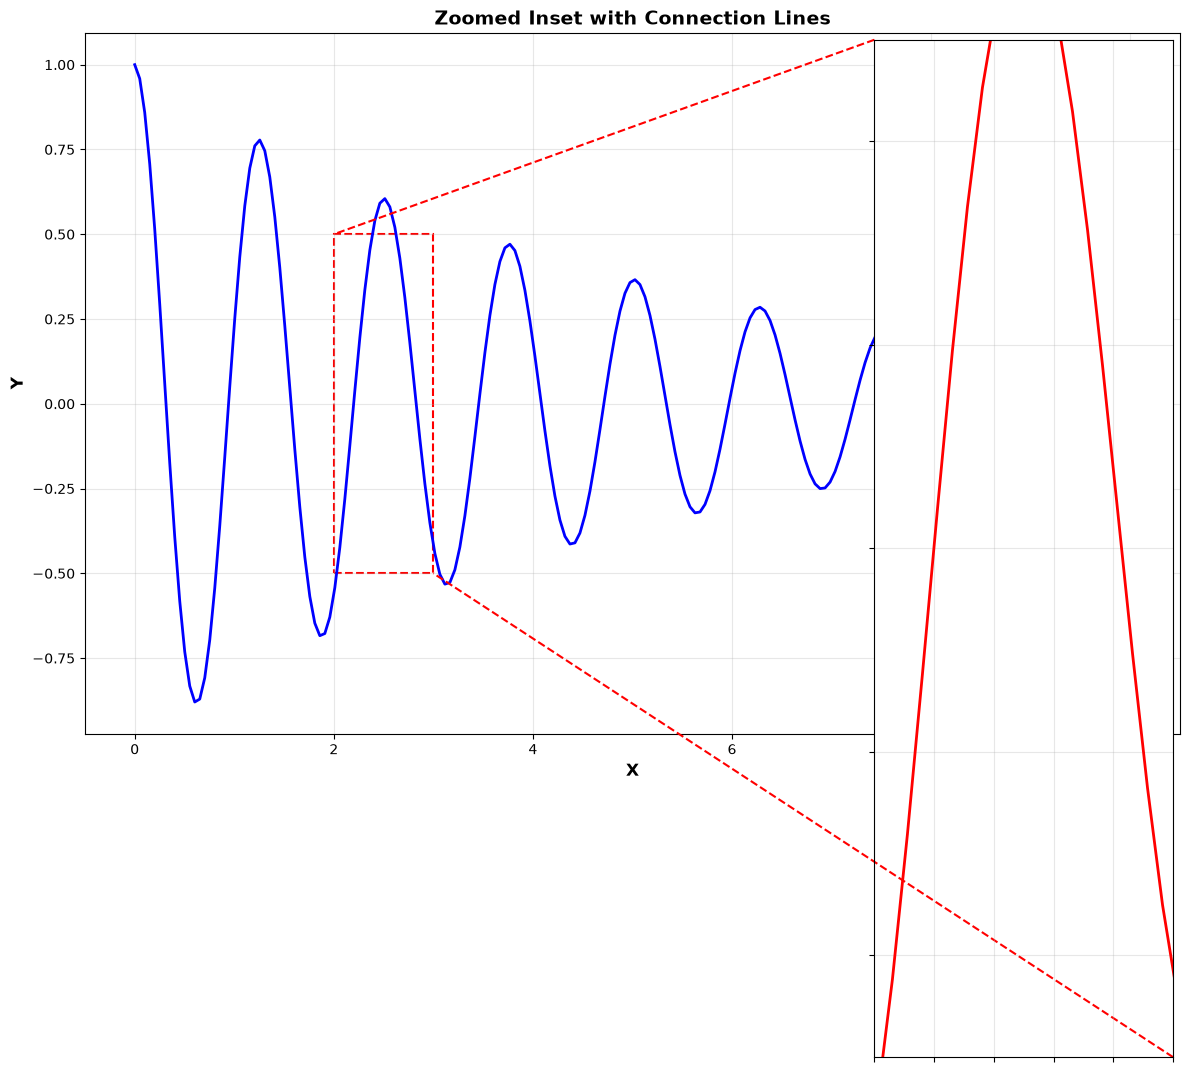

In [3]:
# Generate data
x = np.linspace(0, 10, 200)
y = np.exp(-x/5) * np.cos(5*x)

fig, ax = plt.subplots(figsize=(12, 8))

# Main plot
ax.plot(x, y, 'b-', linewidth=2)
ax.set_xlabel('X', fontsize=12, fontweight='bold')
ax.set_ylabel('Y', fontsize=12, fontweight='bold')
ax.set_title('Zoomed Inset with Connection Lines', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Create zoomed inset
axins = zoomed_inset_axes(ax, zoom=3, loc='upper right')
axins.plot(x, y, 'r-', linewidth=2)

# Set zoom region
x1, x2, y1, y2 = 2, 3, -0.5, 0.5
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.grid(True, alpha=0.3)

# Remove tick labels from inset
axins.tick_params(labelleft=False, labelbottom=False)

# Draw connection lines
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="red", linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.show()

## 📊 3. Multiple Insets

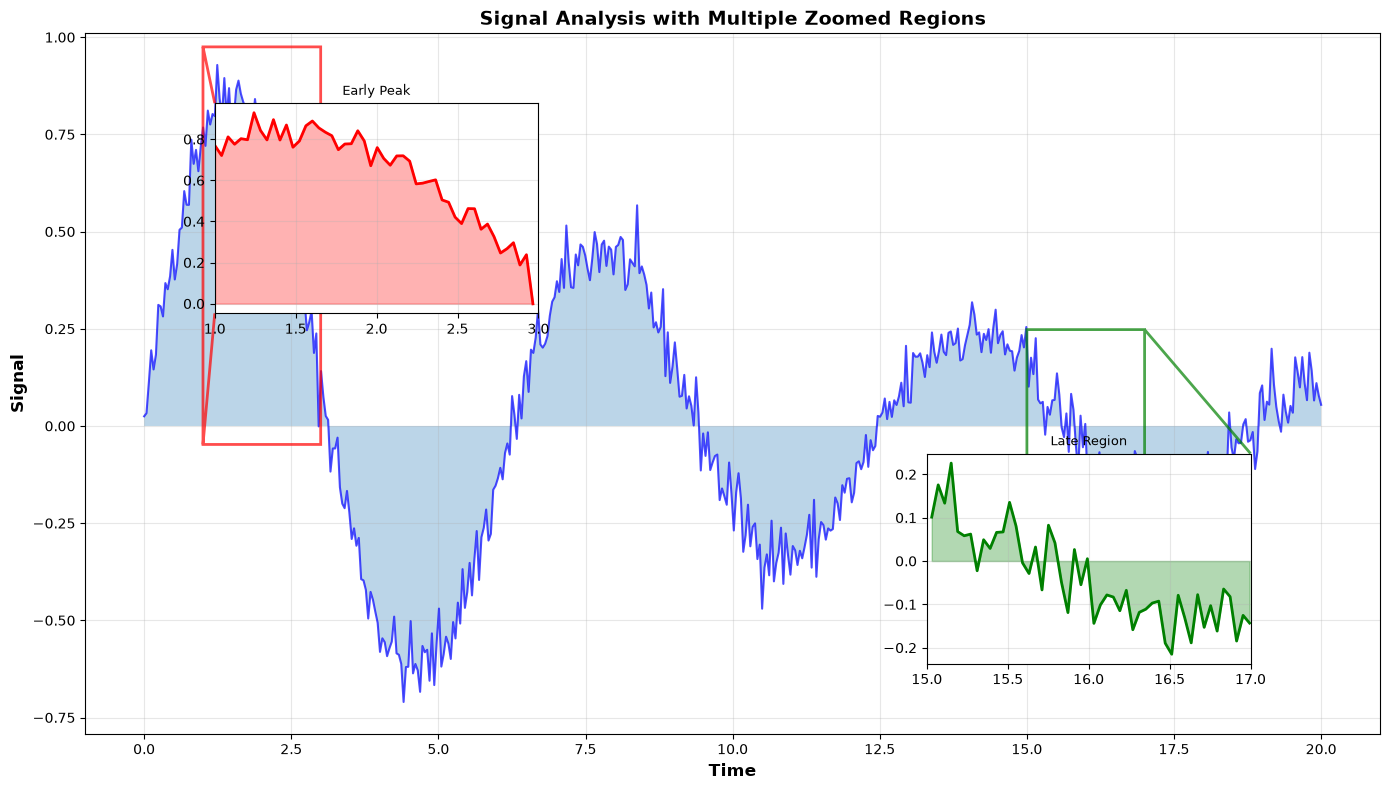

In [4]:
# Generate complex data
np.random.seed(42)
x = np.linspace(0, 20, 500)
y = np.sin(x) * np.exp(-x/10) + 0.05 * np.random.randn(500)

fig, ax = plt.subplots(figsize=(14, 8))

# Main plot
ax.plot(x, y, 'b-', linewidth=1.5, alpha=0.7)
ax.fill_between(x, y, alpha=0.3)
ax.set_xlabel('Time', fontsize=12, fontweight='bold')
ax.set_ylabel('Signal', fontsize=12, fontweight='bold')
ax.set_title('Signal Analysis with Multiple Zoomed Regions', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# First inset - upper left
ax_inset1 = ax.inset_axes([0.1, 0.6, 0.25, 0.3])
zoom_idx1 = np.where((x >= 1) & (x <= 3))[0]
ax_inset1.plot(x[zoom_idx1], y[zoom_idx1], 'r-', linewidth=2)
ax_inset1.fill_between(x[zoom_idx1], y[zoom_idx1], alpha=0.3, color='red')
ax_inset1.set_xlim(1, 3)
ax_inset1.grid(True, alpha=0.3)
ax_inset1.set_title('Early Peak', fontsize=9)
ax.indicate_inset_zoom(ax_inset1, edgecolor='red', linewidth=2, alpha=0.7)

# Second inset - lower right
ax_inset2 = ax.inset_axes([0.65, 0.1, 0.25, 0.3])
zoom_idx2 = np.where((x >= 15) & (x <= 17))[0]
ax_inset2.plot(x[zoom_idx2], y[zoom_idx2], 'g-', linewidth=2)
ax_inset2.fill_between(x[zoom_idx2], y[zoom_idx2], alpha=0.3, color='green')
ax_inset2.set_xlim(15, 17)
ax_inset2.grid(True, alpha=0.3)
ax_inset2.set_title('Late Region', fontsize=9)
ax.indicate_inset_zoom(ax_inset2, edgecolor='green', linewidth=2, alpha=0.7)

plt.tight_layout()
plt.show()

## 🎨 4. Picture-in-Picture: Different Plot Type

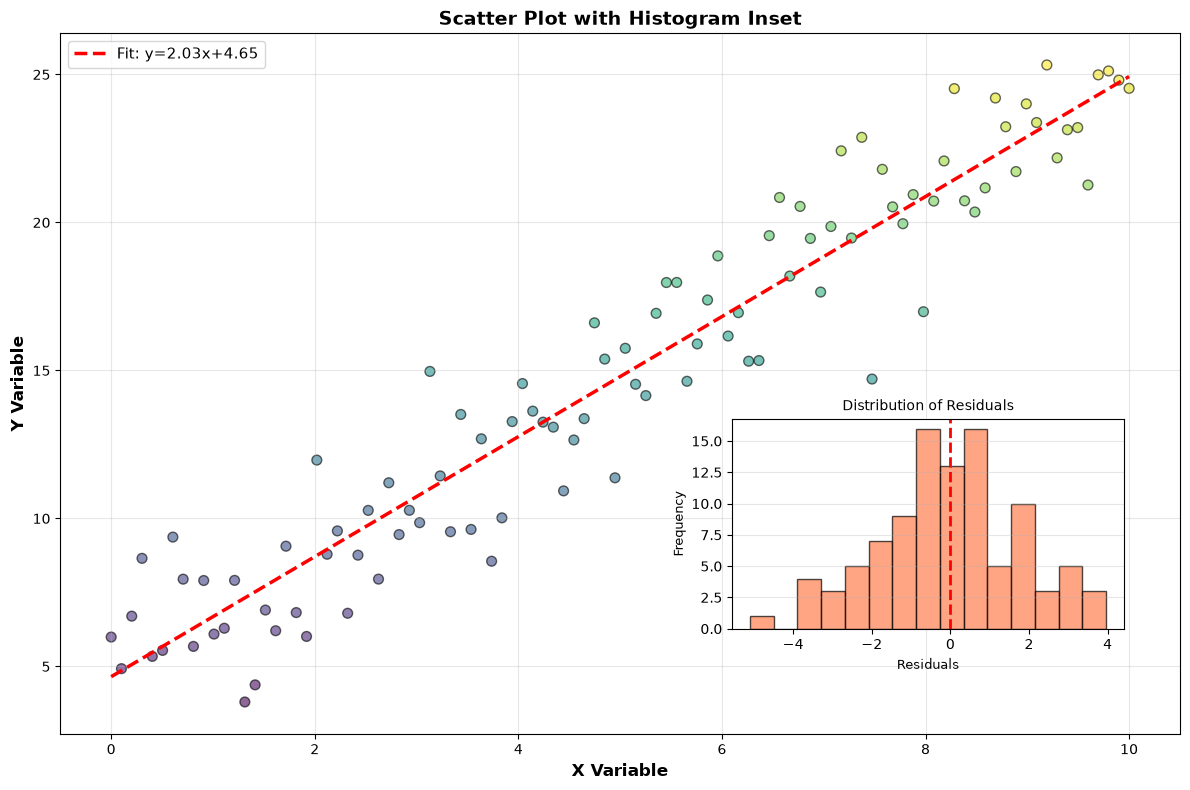

In [5]:
# Generate data
np.random.seed(42)
x = np.linspace(0, 10, 100)
y = 2 * x + 5 + np.random.randn(100) * 2

fig, ax = plt.subplots(figsize=(12, 8))

# Main scatter plot
ax.scatter(x, y, c=y, cmap='viridis', s=50, alpha=0.6, edgecolors='black')

# Add regression line
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax.plot(x, p(x), 'r--', linewidth=2.5, label=f'Fit: y={z[0]:.2f}x+{z[1]:.2f}')

ax.set_xlabel('X Variable', fontsize=12, fontweight='bold')
ax.set_ylabel('Y Variable', fontsize=12, fontweight='bold')
ax.set_title('Scatter Plot with Histogram Inset', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

# Create inset for residuals histogram
ax_inset = ax.inset_axes([0.6, 0.15, 0.35, 0.3])
residuals = y - p(x)
ax_inset.hist(residuals, bins=15, color='coral', alpha=0.7, edgecolor='black')
ax_inset.axvline(0, color='red', linestyle='--', linewidth=2)
ax_inset.set_xlabel('Residuals', fontsize=9)
ax_inset.set_ylabel('Frequency', fontsize=9)
ax_inset.set_title('Distribution of Residuals', fontsize=10)
ax_inset.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 🗺️ 5. Geographic-Style Inset (Overview + Detail)

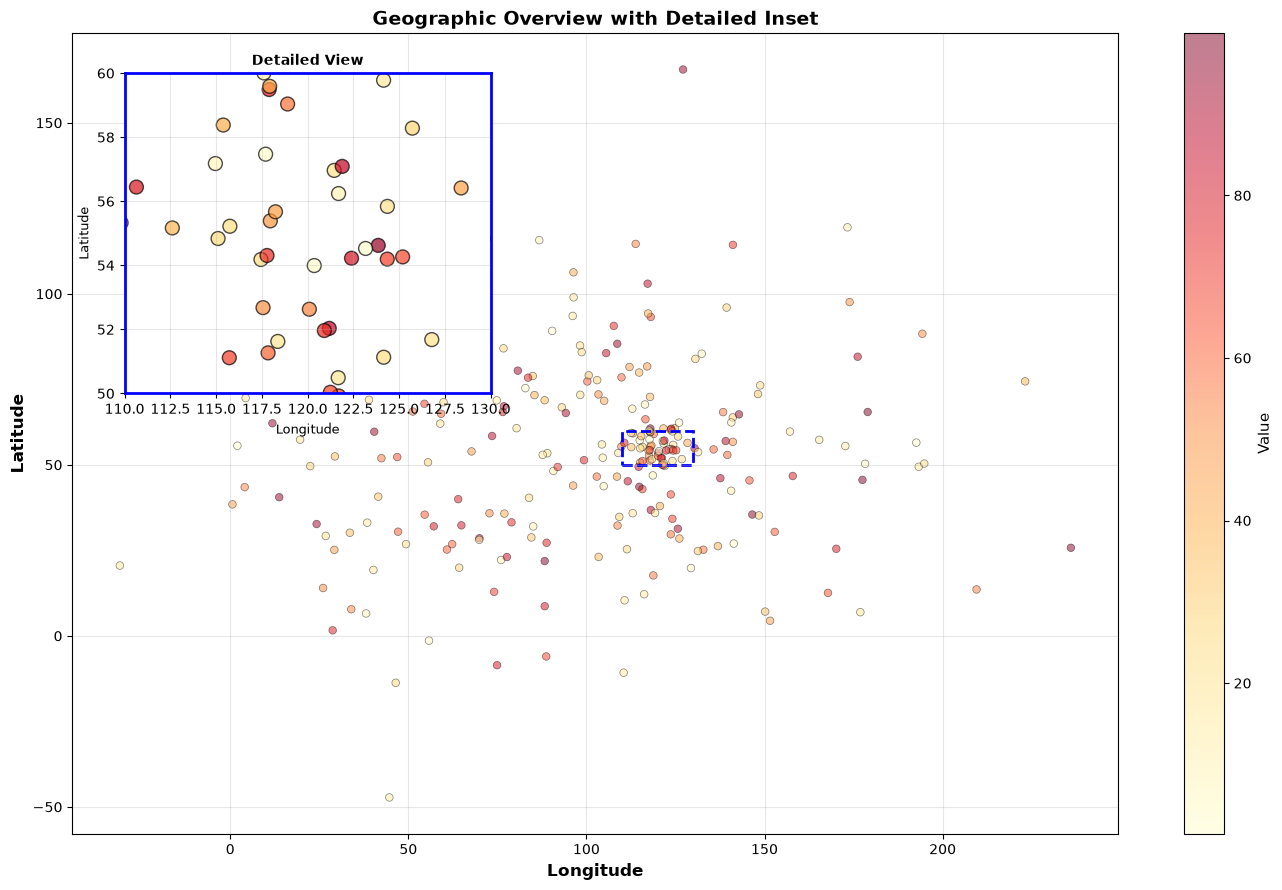

In [6]:
# Simulate geographic data
np.random.seed(42)
n_points = 200
x_full = np.random.randn(n_points) * 50 + 100
y_full = np.random.randn(n_points) * 30 + 50
values = np.random.rand(n_points) * 100

# Create a cluster in one region
x_cluster = np.random.randn(50) * 5 + 120
y_cluster = np.random.randn(50) * 3 + 55
values_cluster = np.random.rand(50) * 100

fig, ax = plt.subplots(figsize=(14, 9))

# Main overview plot
scatter1 = ax.scatter(x_full, y_full, c=values, s=30, alpha=0.5, 
                      cmap='YlOrRd', edgecolors='black', linewidth=0.5)
scatter2 = ax.scatter(x_cluster, y_cluster, c=values_cluster, s=30, 
                      alpha=0.5, cmap='YlOrRd', edgecolors='black', linewidth=0.5)

# Highlight the detailed region
from matplotlib.patches import Rectangle
rect = Rectangle((110, 50), 20, 10, linewidth=2, edgecolor='blue', 
                 facecolor='none', linestyle='--')
ax.add_patch(rect)

ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title('Geographic Overview with Detailed Inset', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Colorbar
cbar = plt.colorbar(scatter1, ax=ax)
cbar.set_label('Value', fontsize=11)

# Detailed inset
ax_inset = ax.inset_axes([0.05, 0.55, 0.35, 0.4])
ax_inset.scatter(x_cluster, y_cluster, c=values_cluster, s=100, 
                alpha=0.7, cmap='YlOrRd', edgecolors='black', linewidth=1)
ax_inset.set_xlim(110, 130)
ax_inset.set_ylim(50, 60)
ax_inset.set_title('Detailed View', fontsize=10, fontweight='bold')
ax_inset.grid(True, alpha=0.3)
ax_inset.set_xlabel('Longitude', fontsize=9)
ax_inset.set_ylabel('Latitude', fontsize=9)

# Add border to inset
for spine in ax_inset.spines.values():
    spine.set_edgecolor('blue')
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()

## 🔬 6. Real-World Example: Scientific Data with Detail View

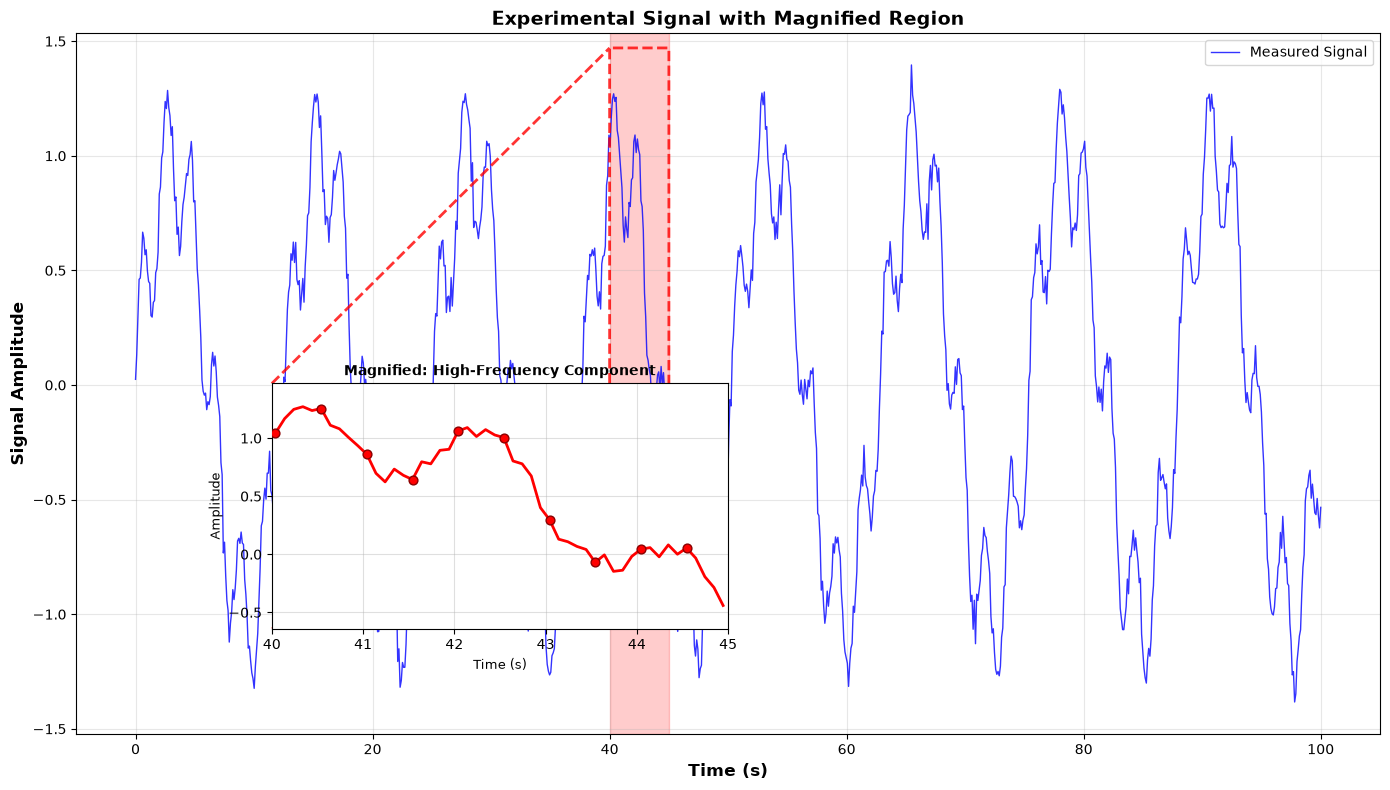

In [7]:
# Simulate experimental data
np.random.seed(42)
time = np.linspace(0, 100, 1000)
signal = np.sin(0.5 * time) + 0.3 * np.sin(3 * time) + 0.05 * np.random.randn(1000)

fig, ax = plt.subplots(figsize=(14, 8))

# Main plot
ax.plot(time, signal, 'b-', linewidth=1, alpha=0.8, label='Measured Signal')
ax.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Signal Amplitude', fontsize=12, fontweight='bold')
ax.set_title('Experimental Signal with Magnified Region', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

# Create magnified inset
ax_mag = ax.inset_axes([0.15, 0.15, 0.35, 0.35])

# Show detail region (zoom into interesting oscillations)
zoom_start, zoom_end = 40, 45
zoom_idx = np.where((time >= zoom_start) & (time <= zoom_end))[0]

ax_mag.plot(time[zoom_idx], signal[zoom_idx], 'r-', linewidth=2)
ax_mag.scatter(time[zoom_idx][::5], signal[zoom_idx][::5], 
               c='red', s=40, zorder=5, edgecolors='darkred')
ax_mag.set_xlim(zoom_start, zoom_end)
ax_mag.set_ylim(signal[zoom_idx].min() - 0.2, signal[zoom_idx].max() + 0.2)
ax_mag.grid(True, alpha=0.4)
ax_mag.set_title('Magnified: High-Frequency Component', fontsize=10, fontweight='bold')
ax_mag.set_xlabel('Time (s)', fontsize=9)
ax_mag.set_ylabel('Amplitude', fontsize=9)

# Highlight region on main plot
ax.axvspan(zoom_start, zoom_end, alpha=0.2, color='red', label='Magnified Region')

# Draw connection
ax.indicate_inset_zoom(ax_mag, edgecolor='red', linewidth=2, linestyle='--', alpha=0.8)

plt.tight_layout()
plt.show()

## 🎯 Key Takeaways

- ✅ Use `inset_axes()` to create picture-in-picture plots
- ✅ `zoomed_inset_axes()` creates magnified views easily
- ✅ `mark_inset()` draws connection lines automatically
- ✅ `indicate_inset_zoom()` highlights the zoomed region
- ✅ Insets can show different plot types (histograms, scatter, etc.)
- ✅ Multiple insets can highlight various regions of interest
- ✅ Position insets using [x, y, width, height] in axes coordinates

## 💡 Try It Yourself

1. Add zoomed views to time series data
2. Show detail regions in geographic plots
3. Display histograms as insets in scatter plots
4. Create multi-scale scientific visualizations
5. Highlight anomalies or interesting features with magnified insets